## Prediksi NO2

In [1]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]2m2/3 [folium]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta
# Tambahkan library lain yang Anda gunakan di sini (misal: streamlit, folium)

print("--- Memulai Proses Pemuatan dan Pembersihan Data ---")

# --- 1. MEMUAT DATA ---
# Langsung muat file CSV Anda
file_name = 'NO2_surabaya_sidoarjo.csv'
try:
    df = pd.read_csv(file_name)
    print(f"Berhasil memuat {file_name}")
except FileNotFoundError:
    print(f"ERROR: File {file_name} tidak ditemukan. Pastikan file ada di folder yang sama.")

# --- 2. PRA-PEMROSESAN (PERBAIKAN) ---
# Ini adalah bagian yang memperbaiki semua error Anda

# 2a. Ganti nama kolom 'time' menjadi 'Tanggal'
if 'time' in df.columns:
    df.rename(columns={'time': 'Tanggal'}, inplace=True)
    print("Berhasil mengganti nama kolom 'time' -> 'Tanggal'")
else:
    print("Peringatan: Kolom 'time' tidak ditemukan (mungkin sudah diganti).")

# 2b. Konversi 'Tanggal' ke format datetime
if 'Tanggal' in df.columns:
    df['Tanggal'] = pd.to_datetime(df['Tanggal'])
    print("Berhasil mengonversi kolom 'Tanggal' ke datetime")
else:
    print("ERROR: Kolom 'Tanggal' tidak ditemukan untuk dikonversi.")

# 2c. Mengisi nilai NO2 yang hilang (NaN)
# Berdasarkan data Anda, ada nilai yang hilang. Ini akan menyebabkan error pada model.
# Kita gunakan interpolasi linear untuk mengisinya.
initial_null_count = df['NO2'].isnull().sum()
if initial_null_count > 0:
    df['NO2'] = df['NO2'].interpolate(method='linear')
    print(f"Berhasil mengisi {initial_null_count} nilai NO2 yang hilang.")

# --- 3. VERIFIKASI ---
# Tampilkan hasil untuk memastikan semuanya benar
print("\n--- Data Final Siap untuk Model ---")
print(df.head())

print("\n--- Info Data Final ---")
df.info()

--- Memulai Proses Pemuatan dan Pembersihan Data ---
Berhasil memuat NO2_surabaya_sidoarjo.csv
Berhasil mengganti nama kolom 'time' -> 'Tanggal'
Berhasil mengonversi kolom 'Tanggal' ke datetime
Berhasil mengisi 114 nilai NO2 yang hilang.

--- Data Final Siap untuk Model ---
     Tanggal       NO2
0 2023-10-15  0.000015
1 2023-10-16  0.000030
2 2023-10-17  0.000033
3 2023-10-18  0.000035
4 2023-10-19  0.000036

--- Info Data Final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tanggal  729 non-null    datetime64[ns]
 1   NO2      729 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.5 KB


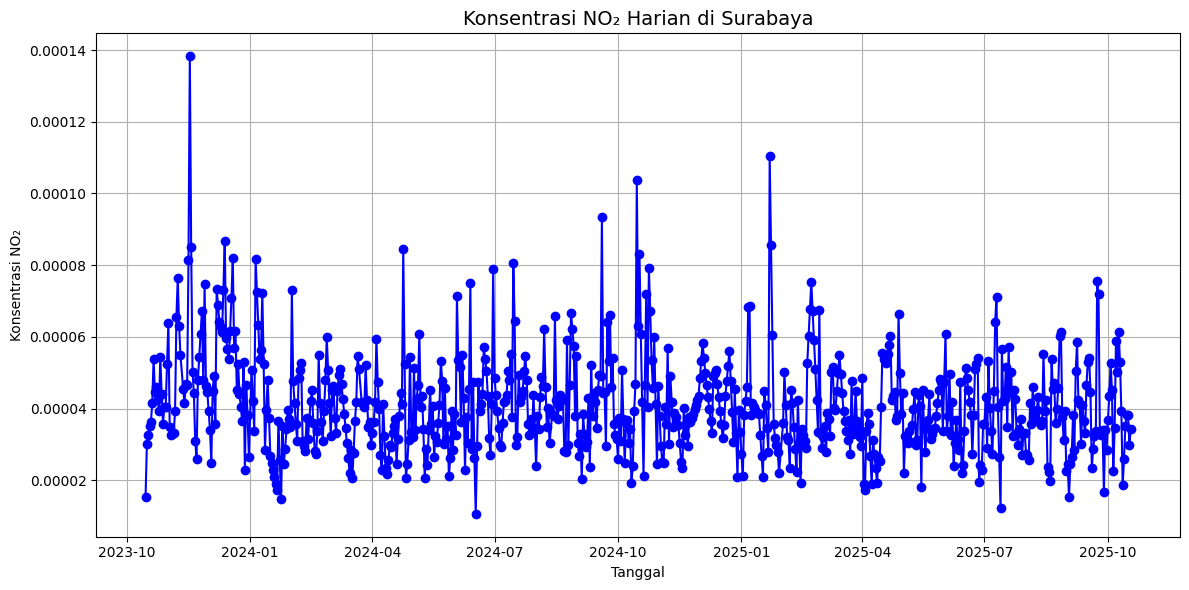

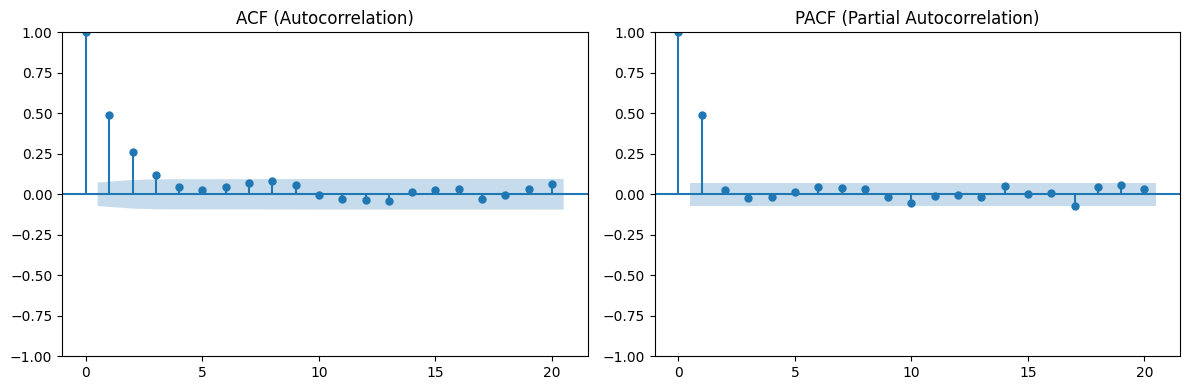

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,6))
plt.plot(df['Tanggal'], df['NO2'], marker='o', linestyle='-', color='blue')
plt.title("Konsentrasi NO₂ Harian di Surabaya", fontsize=14)
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot autokorelasi
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df['NO2'], ax=axes[0], lags=20)
plot_pacf(df['NO2'], ax=axes[1], lags=20)
axes[0].set_title("ACF (Autocorrelation)")
axes[1].set_title("PACF (Partial Autocorrelation)")
plt.tight_layout()
plt.show()


In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['NO2'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

if result[1] > 0.05:
    print("⚠️ Data tidak stasioner → perlu differencing.")
    df['NO2_diff'] = df['NO2'].diff().dropna()
else:
    print("✅ Data sudah stasioner.")


ADF Statistic: -15.77142689122453
p-value: 1.1597482449257049e-28
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}
✅ Data sudah stasioner.


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Bangun model SARIMAX
model = SARIMAX(df['NO2'], order=(1,1,1), seasonal_order=(1,1,1,7))
results = model.fit(disp=False)

print(results.summary())

# Prediksi 7 hari ke depan
future_steps = 7
forecast = results.get_forecast(steps=future_steps)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# Buat tanggal prediksi
last_date = df['Tanggal'].iloc[-1]
future_dates = [last_date + timedelta(days=i) for i in range(1, future_steps+1)]

pred_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi_NO2': pred_mean.values,
    'Lower_CI': pred_ci.iloc[:, 0].values,
    'Upper_CI': pred_ci.iloc[:, 1].values
})

print(pred_df)


                                     SARIMAX Results                                     
Dep. Variable:                               NO2   No. Observations:                  729
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                6871.447
Date:                           Sun, 09 Nov 2025   AIC                         -13732.894
Time:                                   18:25:24   BIC                         -13709.990
Sample:                                        0   HQIC                        -13724.052
                                           - 729                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2701   4.28e-20   6.31e+18      0.000       0.270       0.270
ma.L1         -0.6499   3.03e-20  -2.14e+19

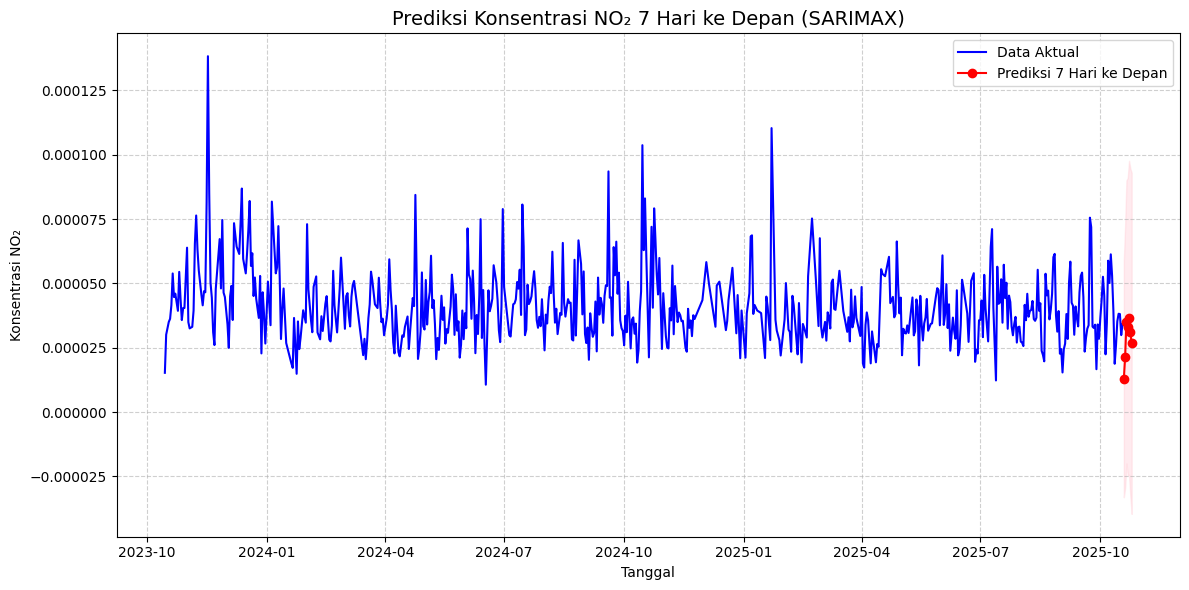

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df['Tanggal'], df['NO2'], label='Data Aktual', color='blue')
plt.plot(pred_df['Tanggal'], pred_df['Prediksi_NO2'], color='red', marker='o', label='Prediksi 7 Hari ke Depan')
plt.fill_between(pred_df['Tanggal'], pred_df['Lower_CI'], pred_df['Upper_CI'], color='pink', alpha=0.3)
plt.title("Prediksi Konsentrasi NO₂ 7 Hari ke Depan (SARIMAX)", fontsize=14)
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [7]:
import folium


# Koordinat Sidoarjo
lat, lon = -7.496, 112.72

# Nilai rata-rata prediksi
mean_pred = pred_df['Prediksi_NO2'].mean()

# Fungsi warna sesuai konsentrasi
def color_scale(val):
    if val < 2.5e-5:
        return 'green'
    elif val < 5e-5:
        return 'orange'
    else:
        return 'red'

m = folium.Map(location=[lat, lon], zoom_start=11)
folium.CircleMarker(
    location=[lat, lon],
    radius=15,
    color=color_scale(mean_pred),
    fill=True,
    fill_opacity=0.6,
    popup=f"Prediksi rata-rata NO₂ (7 hari): {mean_pred:.2e}"
).add_to(m)

m.save("map_no2.html")
m

In [8]:
# Cell 7: Generate app.py untuk Streamlit
# PERBAIKAN: Menambahkan encoding="utf-8" untuk menyimpan emoji
with open("app.py", "w", encoding="utf-8") as f:
    f.write("""
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import timedelta
import folium
from streamlit_folium import st_folium

st.title("🌫️ Prediksi Konsentrasi NO₂ Surabaya (7 Hari ke Depan)")

uploaded_file = st.file_uploader("Upload file CSV NO₂", type="csv")

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    # Perbaikan bug jika file CSV memiliki header aneh
    if df.columns[0] == "Tanggal,NO2":
        # Reset file pointer dan baca ulang
        uploaded_file.seek(0)
        df = pd.read_csv(uploaded_file, names=["Tanggal", "NO2"], skiprows=1)
    
    # Perbaikan dari error Anda sebelumnya (time vs Tanggal)
    if 'time' in df.columns:
        df.rename(columns={'time': 'Tanggal'}, inplace=True)

    df['Tanggal'] = pd.to_datetime(df['Tanggal'])
    df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')
    
    # Mengisi nilai hilang (penting untuk model)
    df['NO2'] = df['NO2'].interpolate(method='linear')
    df = df.dropna(subset=['Tanggal','NO2']).sort_values('Tanggal')

    st.line_chart(df.set_index('Tanggal')['NO2'])

    model = SARIMAX(df['NO2'], order=(1,1,1), seasonal_order=(1,1,1,7))
    results = model.fit(disp=False)
    forecast = results.get_forecast(steps=7)
    pred_mean = forecast.predicted_mean
    future_dates = [df['Tanggal'].iloc[-1] + timedelta(days=i) for i in range(1,8)]
    pred_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_NO2': pred_mean.values})
    
    st.subheader("📅 Prediksi 7 Hari ke Depan")
    st.dataframe(pred_df)

    plt.figure(figsize=(10,5))
    plt.plot(df.set_index('Tanggal')['NO2'], label='Aktual', color='blue')
    plt.plot(pred_df.set_index('Tanggal')['Prediksi_NO2'], color='red', marker='o', label='Prediksi')
    plt.legend()
    st.pyplot(plt)

    lat, lon = -7.2575, 112.7521
    m = folium.Map(location=[lat, lon], zoom_start=11)
    mean_pred = pred_df['Prediksi_NO2'].mean()
    folium.CircleMarker([lat, lon], radius=15, color='red', fill=True,
                        popup=f"Prediksi rata-rata NO₂: {mean_pred:.2e}").add_to(m)
    st_folium(m, width=700)
""")

print("✅ File app.py (UTF-8) siap dijalankan di Streamlit!")

✅ File app.py (UTF-8) siap dijalankan di Streamlit!
